# CheMeleon-Style ChebNet Foundation Pretraining

Dieses Notebook implementiert die vier angefragten Schritte:
1. Datenbeschaffung + Mordred-Deskriptor-Berechnung
2. ChebNet + 2-Layer Pretraining-Head
3. Dynamische Maskierung (85% maskiert, 15% supervised)
4. Training mit Masked MSE

In [2]:
# Optional: in fresh env
# !pip install -r ../../requirements.txt

import sys
from pathlib import Path

import numpy as np
import torch
import zarr

# Ensure project root (folder containing models/) is importable in notebook runs.
here = Path.cwd().resolve()
workspace_root = next(
    (p for p in [here, *here.parents] if (p / "models").exists()),
    here,
    )
if str(workspace_root) not in sys.path:
    sys.path.insert(0, str(workspace_root))

# CheMeleon descriptor archive is Zarr v3; require zarr>=3.
zarr_major = int(zarr.__version__.split('.')[0])
if zarr_major < 3:
    raise RuntimeError(
        f"zarr> =3 required for pubchem_1MM.zarr, found {zarr.__version__}. "
        "Install with: uv pip install --python .venv\\Scripts\\python.exe --upgrade 'zarr>=3'"
    )

from models.chemeleon_pretraining import (
    DEFAULT_DESCRIPTOR_DIM,
    ChebNodePretrainer,
    ChebGraphPretrainer,
    DescriptorPretrainingData,
    DescriptorPretrainingDataset,
    DescriptorTargetStats,
    build_cached_model_differentiator,
    create_pretraining_dataloader,
    load_or_simulate_unlabeled_smiles,
    masked_mse_loss_dynamic,
    preprocess_descriptor_targets,
    save_pretraining_artifacts,
    )

print(f"Workspace root: {workspace_root}")
print(f"zarr version: {zarr.__version__}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

Workspace root: /home/robert/Hiwi/TAME-MPP/molfusion2
zarr version: 3.1.6


device(type='cpu')

## Schritt 1: SMILES laden + vorliegende Zarr-Deskriptoren verwenden

Dieses Notebook berechnet keine Mordred-Deskriptoren neu.
Stattdessen werden die bereits vorberechneten 1613 Targets aus `cache/pubchem_1MM.zarr` geladen.

In [3]:
from pathlib import Path

# Nutze feste Pfade relativ zum Workspace-Root (nicht relativ zum aktuellen CWD).
cache_dir = workspace_root / 'cache'
smiles_source = cache_dir / 'cleaned_pubchem_1MM.smiles'
zarr_source = cache_dir / 'pubchem_1MM.zarr'

if not smiles_source.exists():
    raise FileNotFoundError(f'SMILES file not found: {smiles_source.resolve()}')
if not zarr_source.exists():
    raise FileNotFoundError(f'Zarr descriptor file not found: {zarr_source.resolve()}')

# Fuer den vollen Lauf auf 944_296 setzen (Zarr-Zeilenzahl).
max_smiles = 600000

smiles_list = load_or_simulate_unlabeled_smiles(
    smiles_path=str(smiles_source),
    max_smiles=max_smiles,
    simulate_if_missing=False,
    seed=42,
    suppress_rdkit_errors=True,
 )

# Zarr v3 array direkt oeffnen
z = zarr.open_array(str(zarr_source), mode='r')
print('SMILES loaded:', len(smiles_list))
print('Zarr shape:', z.shape)

SMILES loaded: 600000
Zarr shape: (944296, 1613)


In [ ]:
# Align SMILES with available Zarr rows
z = zarr.open_array(str(zarr_source), mode='r')
n = min(len(smiles_list), int(z.shape[0]))
descriptor_matrix = np.asarray(z[:n, :], dtype=np.float32)

# Determine usable descriptor columns first (finite coverage + non-zero variance).
finite_mask = np.isfinite(descriptor_matrix)
valid_fraction = finite_mask.mean(axis=0)
col_std = np.nanstd(descriptor_matrix, axis=0)
usable_count = int(np.sum((valid_fraction >= 0.95) & (col_std > 1e-8)))
if usable_count < DEFAULT_DESCRIPTOR_DIM:
    usable_count = int(np.sum(col_std > 1e-8))

effective_output_dim = min(DEFAULT_DESCRIPTOR_DIM, usable_count)
if effective_output_dim <= 0:
    raise RuntimeError('No usable descriptor columns found in Zarr descriptors.')

# Reuse existing preprocessing (normalization, clipping, valid-mask handling).
feature_names = [f'mordred_{i:04d}' for i in range(descriptor_matrix.shape[1])]
targets, target_valid_mask, stats = preprocess_descriptor_targets(
    descriptor_matrix,
    feature_names,
    output_dim=effective_output_dim,
    min_valid_fraction=0.95,
 )

pre_data = DescriptorPretrainingData(
    smiles=smiles_list[:n],
    targets=targets,
    target_valid_mask=target_valid_mask,
    stats=DescriptorTargetStats(
        feature_names=stats.feature_names,
        mean=stats.mean,
        std=stats.std,
        selected_indices=stats.selected_indices,
    ),
 )

PRETRAIN_DESCRIPTOR_DIM = pre_data.targets.shape[1]

print('SMILES source:', smiles_source.resolve())
print('Zarr source:', zarr_source.resolve())
print('Prepared rows:', len(pre_data.smiles))
print('Targets shape:', pre_data.targets.shape)
print('Valid mask shape:', pre_data.target_valid_mask.shape)
print('Descriptor count (selected):', len(pre_data.stats.feature_names))
print('Requested descriptor_dim:', DEFAULT_DESCRIPTOR_DIM)
print('Usable descriptors:', usable_count)
print('Effective descriptor_dim:', PRETRAIN_DESCRIPTOR_DIM)

if PRETRAIN_DESCRIPTOR_DIM < 1500:
    raise RuntimeError(f'Unexpectedly low descriptor_dim: {PRETRAIN_DESCRIPTOR_DIM}')

# Persist once so large-scale runs can be resumed quickly
art_dir = Path('../../cache/chemeleon_pretraining')
save_pretraining_artifacts(str(art_dir), pre_data)
print('Saved artifacts to', art_dir.resolve())

## Schritt 2: Modell-Setup fuer 2-Stage Pretraining

Dieses Notebook nutzt jetzt explizit zwei aufeinanderfolgende Stufen:
1. Stage 1 (Node-Level): Attribute Masking mit Atomtyp-Vorhersage
2. Stage 2 (Graph-Level): Descriptor Prediction mit Dynamic Masking Loss

Die Encoder-Architektur bleibt in beiden Stufen identisch, damit die Gewichte aus Stage 1 direkt in Stage 2 geladen werden koennen.

In [ ]:
dataset = DescriptorPretrainingDataset(
    smiles=pre_data.smiles,
    targets=pre_data.targets,
    target_valid_mask=pre_data.target_valid_mask,
    add_hydrogens=False,
    )

train_loader = create_pretraining_dataloader(
    dataset,
    batch_size=64,
    shuffle=True,
    num_workers=0,
    )

# Shared encoder config for Stage 1 and Stage 2.
# Keep both stages architecturally aligned to enable weight transfer.
PRETRAIN_CHEB_CFG = {
    "hidden_channels":128,
    "K": 3,
    "num_layers": 3,
    "pool": "sum",
    "dropout": 0.2,
    "head_hidden_dim": 256,
}

# Central run-mode switch: "stage1_only", "stage2_only", or "stage1_stage2".
PRETRAIN_RUN_MODE = "stage1_only"

# Stage-1 (node-level masking) settings.
STAGE1_CFG = {
    "mask_fraction": 0.25,
    "num_epochs": 7,
    "batch_size": 64,
    "learning_rate": 1e-3,
    "weight_decay": 1e-5,
}

# Stage-2 (graph-level descriptor) settings.
# In "stage2_only" mode, this cell will load a Stage-1 checkpoint from init_stage1_ckpt.
STAGE2_CFG = {
    "keep_fraction": 0.15,
    "num_epochs": 7,
    "batch_size": 64,
    "learning_rate": 1e-3,
    "weight_decay": 1e-5,
    "init_stage1_ckpt": "../../cache/chemeleon_pretraining/cheb_foundation_pretrain_stage1.pt",
}

print("Pretrain encoder config:", PRETRAIN_CHEB_CFG)
print("Pretraining run mode:", PRETRAIN_RUN_MODE)
print("Stage 1 config:", STAGE1_CFG)
print("Stage 2 config:", STAGE2_CFG)

stage1_model = ChebNodePretrainer(
    in_channels=dataset.in_channels,
    hidden_channels=PRETRAIN_CHEB_CFG["hidden_channels"],
    K=PRETRAIN_CHEB_CFG["K"],
    num_layers=PRETRAIN_CHEB_CFG["num_layers"],
    dropout=PRETRAIN_CHEB_CFG["dropout"],
    atom_type_dim=10,
).to(device)

stage2_model = ChebGraphPretrainer(
    in_channels=dataset.in_channels,
    descriptor_dim=PRETRAIN_DESCRIPTOR_DIM,
    hidden_channels=PRETRAIN_CHEB_CFG["hidden_channels"],
    K=PRETRAIN_CHEB_CFG["K"],
    num_layers=PRETRAIN_CHEB_CFG["num_layers"],
    dropout=PRETRAIN_CHEB_CFG["dropout"],
    pooling=PRETRAIN_CHEB_CFG["pool"],
    head_hidden_dim=PRETRAIN_CHEB_CFG["head_hidden_dim"],
).to(device)

n_stage1 = sum(p.numel() for p in stage1_model.parameters())
n_stage2 = sum(p.numel() for p in stage2_model.parameters())
print({"stage1_params": n_stage1, "stage2_params": n_stage2})

[21:24:07] WARNING: not removing hydrogen atom without neighbors
[21:24:08] WARNING: not removing hydrogen atom without neighbors
[21:24:27] WARNING: not removing hydrogen atom without neighbors
[21:24:35] WARNING: not removing hydrogen atom without neighbors
[21:24:35] WARNING: not removing hydrogen atom without neighbors


Pretrain encoder config: {'hidden_channels': 128, 'K': 3, 'num_layers': 3, 'pool': 'sum', 'dropout': 0.2, 'head_hidden_dim': 256}
Pretraining run mode: stage1_only
Stage 1 config: {'mask_fraction': 0.25, 'num_epochs': 7, 'batch_size': 64, 'learning_rate': 0.001, 'weight_decay': 1e-05}
Stage 2 config: {'keep_fraction': 0.15, 'num_epochs': 7, 'batch_size': 64, 'learning_rate': 0.001, 'weight_decay': 1e-05, 'init_stage1_ckpt': '../../cache/chemeleon_pretraining/cheb_foundation_pretrain_stage1.pt'}
{'stage1_params': 110758, 'stage2_params': 551608}


## Schritt 3 + 4: Stage 1 + Stage 2 Training

Ablauf:
1. Stage 1: Node-Attribute-Masking (15% maskierte Knoten, CE-Loss nur auf maskierten Knoten)
2. Stage 2: Descriptor Prediction mit Stage-1 Encoder-Init und Dynamic Masking (85% Targets maskiert, Masked MSE auf 15%)

Das beste Stage-2 Modell wird nach `val_masked_mse` ausgewaehlt.

In [ ]:
# --- configurable pretraining: stage1_only, stage2_only, or stage1_stage2 ---
# 1) Train/Val split on pretraining corpus
val_fraction = 0.1
rng_split = np.random.default_rng(42)
all_idx = np.arange(len(pre_data.smiles))
rng_split.shuffle(all_idx)
n_val = max(1, int(len(all_idx) * val_fraction))
val_idx = np.sort(all_idx[:n_val])
train_idx = np.sort(all_idx[n_val:])

train_data = DescriptorPretrainingData(
    smiles=[pre_data.smiles[i] for i in train_idx.tolist()],
    targets=pre_data.targets[train_idx],
    target_valid_mask=pre_data.target_valid_mask[train_idx],
    stats=pre_data.stats,
)
val_data = DescriptorPretrainingData(
    smiles=[pre_data.smiles[i] for i in val_idx.tolist()],
    targets=pre_data.targets[val_idx],
    target_valid_mask=pre_data.target_valid_mask[val_idx],
    stats=pre_data.stats,
)

train_dataset = DescriptorPretrainingDataset(
    smiles=train_data.smiles,
    targets=train_data.targets,
    target_valid_mask=train_data.target_valid_mask,
    add_hydrogens=False,
)

val_dataset = DescriptorPretrainingDataset(
    smiles=val_data.smiles,
    targets=val_data.targets,
    target_valid_mask=val_data.target_valid_mask,
    add_hydrogens=False,
)

train_loader = create_pretraining_dataloader(
    train_dataset,
    batch_size=int(STAGE2_CFG["batch_size"]),
    shuffle=True,
    num_workers=0,
)

val_loader = create_pretraining_dataloader(
    val_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=0,
)

print(f"Pretraining split -> train={len(train_dataset)}, val={len(val_dataset)}")

PRETRAIN_RUN_MODE = str(globals().get("PRETRAIN_RUN_MODE", "stage1_stage2")).strip().lower()
if PRETRAIN_RUN_MODE not in {"stage1_stage2", "stage1_only", "stage2_only"}:
    raise ValueError(
        f"Unsupported PRETRAIN_RUN_MODE='{PRETRAIN_RUN_MODE}'. "
        "Use 'stage1_stage2', 'stage1_only', or 'stage2_only'."
    )
RUN_STAGE1 = PRETRAIN_RUN_MODE in {"stage1_stage2", "stage1_only"}
RUN_STAGE2 = PRETRAIN_RUN_MODE in {"stage1_stage2", "stage2_only"}
print("Pretraining run mode:", PRETRAIN_RUN_MODE)

def _move_batch_to_device(batch, dev):
    return {k: v.to(dev, non_blocking=True) for k, v in batch.items()}

def run_stage1_node_pretraining(model, loader, *, num_epochs, mask_fraction, lr, weight_decay, seed=42, verbose=True):
    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    history = {"train_ce": []}
    g = torch.Generator(device=device.type)
    g.manual_seed(int(seed))

    for epoch in range(1, int(num_epochs) + 1):
        model.train()
        total_loss = 0.0
        n_batches = 0

        for batch in loader:
            batch = _move_batch_to_device(batch, device)
            out = model(
                batch["x"],
                batch["edge_index"],
                batch["edge_weight"],
                batch["batch"],
                mask_fraction=float(mask_fraction),
                generator=g,
            )
            loss = out["loss"]

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()

            total_loss += float(loss.item())
            n_batches += 1

        avg_loss = total_loss / max(n_batches, 1)
        history["train_ce"].append(avg_loss)
        if verbose:
            print(f"[stage1] epoch {epoch:03d} | train_node_ce={avg_loss:.6f}")

    return model, history

def load_stage1_weights_into_stage2_model(stage2_model, checkpoint_path):
    ckpt = torch.load(checkpoint_path, map_location=device, weights_only=False)
    if not isinstance(ckpt, dict):
        raise RuntimeError("Invalid stage1 checkpoint payload format.")

    ckpt_stage = str(ckpt.get("pretraining_stage", ""))
    if ckpt_stage != "stage1_node":
        raise RuntimeError(
            f"Expected stage1 checkpoint (pretraining_stage='stage1_node'), got {ckpt_stage!r}"
        )

    model_state = ckpt.get("model_state_dict", {})
    enc_state = {k.replace("encoder.", "", 1): v for k, v in model_state.items() if k.startswith("encoder.")}
    if not enc_state:
        raise RuntimeError("Checkpoint does not contain encoder.* weights.")

    stage2_model._encoder.load_state_dict(enc_state, strict=True)
    print(f"Loaded Stage-1 encoder from: {Path(checkpoint_path).resolve()}")

def run_stage2_descriptor_pretraining(
    model,
    train_loader,
    val_loader,
    *,
    keep_fraction,
    num_epochs,
    lr,
    weight_decay,
    seed=42,
    verbose=True,
):
    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    hist = {"train_loss": [], "val_loss": []}
    best_val = float("inf")
    best_state = None
    best_epoch = -1
    g = torch.Generator(device=device.type)
    g.manual_seed(int(seed))

    for epoch in range(1, int(num_epochs) + 1):
        model.train()
        train_loss_num = 0.0
        train_loss_den = 0

        for batch in train_loader:
            batch = _move_batch_to_device(batch, device)
            preds = model(
                batch["x"],
                batch["edge_index"],
                batch["edge_weight"],
                batch["batch"],
            )
            loss, dyn_mask = masked_mse_loss_dynamic(
                preds,
                batch["targets"],
                batch["target_valid_mask"],
                keep_fraction=float(keep_fraction),
                generator=g,
            )

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()

            n_sup = int(dyn_mask.sum().item())
            train_loss_num += float(loss.item()) * max(n_sup, 1)
            train_loss_den += n_sup

        train_epoch_loss = train_loss_num / max(train_loss_den, 1)
        hist["train_loss"].append(float(train_epoch_loss))

        model.eval()
        val_loss_num = 0.0
        val_loss_den = 0
        with torch.no_grad():
            for batch in val_loader:
                batch = _move_batch_to_device(batch, device)
                preds = model(
                    batch["x"],
                    batch["edge_index"],
                    batch["edge_weight"],
                    batch["batch"],
                )
                loss, dyn_mask = masked_mse_loss_dynamic(
                    preds,
                    batch["targets"],
                    batch["target_valid_mask"],
                    keep_fraction=float(keep_fraction),
                    generator=g,
                )
                n_sup = int(dyn_mask.sum().item())
                val_loss_num += float(loss.item()) * max(n_sup, 1)
                val_loss_den += n_sup

        val_epoch_loss = val_loss_num / max(val_loss_den, 1)
        hist["val_loss"].append(float(val_epoch_loss))

        if val_epoch_loss < best_val:
            best_val = float(val_epoch_loss)
            best_epoch = int(epoch)
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        if verbose:
            print(
                f"[stage2] epoch {epoch:03d} | "
                f"train_masked_mse={train_epoch_loss:.6f} | val_masked_mse={val_epoch_loss:.6f}"
            )

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, hist, float(best_val), int(best_epoch)

stage1_model = None
stage1_history = {"train_ce": []}

if RUN_STAGE1:
    stage1_loader = create_pretraining_dataloader(
        train_dataset,
        batch_size=int(STAGE1_CFG["batch_size"]),
        shuffle=True,
        num_workers=0,
    )

    stage1_model = ChebNodePretrainer(
        in_channels=train_dataset.in_channels,
        hidden_channels=PRETRAIN_CHEB_CFG["hidden_channels"],
        K=PRETRAIN_CHEB_CFG["K"],
        num_layers=PRETRAIN_CHEB_CFG["num_layers"],
        dropout=PRETRAIN_CHEB_CFG["dropout"],
        atom_type_dim=10,
).to(device)

    stage1_model, stage1_history = run_stage1_node_pretraining(
        stage1_model,
        stage1_loader,
        num_epochs=STAGE1_CFG["num_epochs"],
        mask_fraction=STAGE1_CFG["mask_fraction"],
        lr=STAGE1_CFG["learning_rate"],
        weight_decay=STAGE1_CFG["weight_decay"],
        seed=42,
        verbose=True,
    )

if RUN_STAGE2:
    # Stage 2: descriptor pretraining with encoder initialization from either
    # freshly trained Stage 1 (stage1_stage2) or an external Stage-1 checkpoint (stage2_only).
    model = ChebGraphPretrainer(
        in_channels=train_dataset.in_channels,
        descriptor_dim=PRETRAIN_DESCRIPTOR_DIM,
        hidden_channels=PRETRAIN_CHEB_CFG["hidden_channels"],
        K=PRETRAIN_CHEB_CFG["K"],
        num_layers=PRETRAIN_CHEB_CFG["num_layers"],
        dropout=PRETRAIN_CHEB_CFG["dropout"],
        pooling=PRETRAIN_CHEB_CFG["pool"],
        head_hidden_dim=PRETRAIN_CHEB_CFG["head_hidden_dim"],
    ).to(device)

    if RUN_STAGE1 and stage1_model is not None:
        model.load_encoder_from_stage1(stage1_model)
        print("Initialized Stage-2 encoder from in-memory Stage-1 model.")
    else:
        init_ckpt = Path(STAGE2_CFG.get("init_stage1_ckpt", "../../cache/chemeleon_pretraining/cheb_foundation_pretrain_stage1.pt"))
        if not init_ckpt.exists():
            raise FileNotFoundError(
                f"Stage2-only mode requires a Stage-1 checkpoint. Not found: {init_ckpt.resolve()}"
            )
        load_stage1_weights_into_stage2_model(model, init_ckpt)

    PRETRAIN_KEEP_FRACTION = float(STAGE2_CFG["keep_fraction"])
    PRETRAIN_NUM_EPOCHS = int(STAGE2_CFG["num_epochs"])
    model, history, PRETRAIN_BEST_VAL, PRETRAIN_BEST_EPOCH = run_stage2_descriptor_pretraining(
        model,
        train_loader,
        val_loader,
        keep_fraction=PRETRAIN_KEEP_FRACTION,
        num_epochs=PRETRAIN_NUM_EPOCHS,
        lr=STAGE2_CFG["learning_rate"],
        weight_decay=STAGE2_CFG["weight_decay"],
        seed=42,
        verbose=True,
    )

    PRETRAIN_BEST_VAL = float(PRETRAIN_BEST_VAL)
    PRETRAIN_BEST_EPOCH = int(PRETRAIN_BEST_EPOCH)
    PRETRAIN_STAGE_LABEL = "stage2_descriptor"

    print("\nSelected pretraining setting:")
    print(
        {
            "stage_mode": PRETRAIN_RUN_MODE,
            "stage1_mask_fraction": float(STAGE1_CFG["mask_fraction"]) if RUN_STAGE1 else None,
            "stage1_epochs": int(STAGE1_CFG["num_epochs"]) if RUN_STAGE1 else 0,
            "stage2_keep_fraction": PRETRAIN_KEEP_FRACTION,
            "stage2_epochs": PRETRAIN_NUM_EPOCHS,
            "best_val_masked_mse": PRETRAIN_BEST_VAL,
            "best_epoch": PRETRAIN_BEST_EPOCH,
        }
    )
    if stage1_history["train_ce"]:
        print("Stage1 first/last CE:", stage1_history["train_ce"][0], stage1_history["train_ce"][-1])
    print("Stage2 first/last MSE:", history["train_loss"][0], history["train_loss"][-1])
else:
    # Stage-1-only mode: save node-level pretraining directly.
    if stage1_model is None or not stage1_history["train_ce"]:
        raise RuntimeError("stage1_only selected, but Stage-1 training did not run.")

    model = stage1_model
    history = {"train_loss": [float(x) for x in stage1_history["train_ce"]], "val_loss": []}
    PRETRAIN_KEEP_FRACTION = None
    PRETRAIN_NUM_EPOCHS = 0
    PRETRAIN_BEST_VAL = float(np.min(stage1_history["train_ce"]))
    PRETRAIN_BEST_EPOCH = int(np.argmin(stage1_history["train_ce"]) + 1)
    PRETRAIN_STAGE_LABEL = "stage1_node"

    print("\nSelected pretraining setting:")
    print(
        {
            "stage_mode": PRETRAIN_RUN_MODE,
            "stage1_mask_fraction": float(STAGE1_CFG["mask_fraction"]),
            "stage1_epochs": int(STAGE1_CFG["num_epochs"]),
            "best_train_node_ce": PRETRAIN_BEST_VAL,
            "best_epoch": PRETRAIN_BEST_EPOCH,
        }
    )
    print("Stage1 first/last CE:", stage1_history["train_ce"][0], stage1_history["train_ce"][-1])

history

[21:26:38] WARNING: not removing hydrogen atom without neighbors
[21:26:38] WARNING: not removing hydrogen atom without neighbors
[21:26:55] WARNING: not removing hydrogen atom without neighbors
[21:27:03] WARNING: not removing hydrogen atom without neighbors
[21:28:52] WARNING: not removing hydrogen atom without neighbors


Pretraining split -> train=540000, val=60000
Pretraining run mode: stage1_only
[stage1] epoch 001 | train_node_ce=0.408319
[stage1] epoch 002 | train_node_ce=0.321615
[stage1] epoch 003 | train_node_ce=0.303890
[stage1] epoch 004 | train_node_ce=0.294753
[stage1] epoch 005 | train_node_ce=0.289889
[stage1] epoch 006 | train_node_ce=0.284664
[stage1] epoch 007 | train_node_ce=0.281075

Selected pretraining setting:
{'stage_mode': 'stage1_only', 'stage1_mask_fraction': 0.25, 'stage1_epochs': 7, 'best_train_node_ce': 0.28107513869492523, 'best_epoch': 7}
Stage1 first/last CE: 0.40831878659114307 0.28107513869492523


{'train_loss': [0.40831878659114307,
  0.3216149458746883,
  0.30388966682546936,
  0.2947525917568967,
  0.2898892376922437,
  0.2846636097700739,
  0.28107513869492523],
 'val_loss': []}

In [ ]:
# Checkpoint speichern mit kompaktem stage-spezifischem Namen.
ckpt_dir = Path('../../cache/chemeleon_pretraining')
ckpt_dir.mkdir(parents=True, exist_ok=True)

def _fmt_float_for_name(x):
    s = f"{float(x):.4f}"
    return s.replace('.', 'p')

stage_label = str(globals().get('PRETRAIN_STAGE_LABEL', 'stage2_descriptor'))
is_stage1_only = stage_label == 'stage1_node'
stage_prefix = 'cheb_foundation_stage1' if is_stage1_only else 'cheb_foundation_2stage'

subset_n = len(pre_data.smiles)
train_n = len(train_dataset) if 'train_dataset' in globals() else subset_n
val_n = len(val_dataset) if 'val_dataset' in globals() else 0

stage_cache_tag = build_cached_model_differentiator(
    stage=stage_label,
    config={
        'cheb_cfg': PRETRAIN_CHEB_CFG,
        'stage1_cfg': STAGE1_CFG,
        'stage2_cfg': STAGE2_CFG if not is_stage1_only else None,
        'run_mode': globals().get('PRETRAIN_RUN_MODE', 'stage1_stage2'),
        'descriptor_dim': int(PRETRAIN_DESCRIPTOR_DIM),
    },
    prefix=stage_prefix,
)

# Gewuenschter kurzer Dateiname, damit Windows-Pfadgrenzen nicht getroffen werden.
# Beispiel: cheb_foundation_stage1__h128__L3__K3__pool-set2set__drop-0p2000__head-256__dim-1592__subset-400000.pt
ckpt_stem = '__'.join([
    stage_prefix,
    f"h{PRETRAIN_CHEB_CFG['hidden_channels']}",
    f"L{PRETRAIN_CHEB_CFG['num_layers']}",
    f"K{PRETRAIN_CHEB_CFG['K']}",
    f"pool-{PRETRAIN_CHEB_CFG['pool']}",
    f"drop-{_fmt_float_for_name(PRETRAIN_CHEB_CFG['dropout'])}",
    f"head-{PRETRAIN_CHEB_CFG['head_hidden_dim']}",
    f"dim-{PRETRAIN_DESCRIPTOR_DIM}",
    f"subset-{subset_n}",
])
ckpt_name = ckpt_stem + '.pt'
ckpt_path = ckpt_dir / ckpt_name

# Stable convenience path for downstream cells.
latest_ckpt_name = 'cheb_foundation_pretrain_stage1.pt' if is_stage1_only else 'cheb_foundation_pretrain.pt'
latest_ckpt_path = ckpt_dir / latest_ckpt_name

payload = {
    'model_state_dict': model.state_dict(),
    'in_channels': train_dataset.in_channels if 'train_dataset' in globals() else dataset.in_channels,
    'descriptor_dim': PRETRAIN_DESCRIPTOR_DIM,
    'history': history,
    'stage1_history': stage1_history if 'stage1_history' in globals() else None,
    'descriptor_names': pre_data.stats.feature_names,
    'descriptor_mean': pre_data.stats.mean,
    'descriptor_std': pre_data.stats.std,
    'selected_indices': pre_data.stats.selected_indices,
    'cheb_cfg': PRETRAIN_CHEB_CFG,
    'stage1_cfg': STAGE1_CFG,
    'stage2_cfg': STAGE2_CFG if not is_stage1_only else None,
    'keep_fraction': PRETRAIN_KEEP_FRACTION if not is_stage1_only else None,
    'best_val_masked_mse': None if is_stage1_only else PRETRAIN_BEST_VAL,
    'best_epoch': PRETRAIN_BEST_EPOCH,
    'subset_n': subset_n,
    'train_n': train_n,
    'val_n': val_n,
    'checkpoint_name': ckpt_name,
    'pretraining_stage': stage_label,
    'run_mode': globals().get('PRETRAIN_RUN_MODE', 'stage1_stage2'),
    'cache_differentiator': stage_cache_tag,
}

try:
    torch.save(payload, ckpt_path)
except RuntimeError as e:
    # Fallback bleibt als Sicherheitsnetz erhalten, sollte mit kurzem Namen aber kaum noch greifen.
    fallback_name = f"{stage_prefix}__fallback.pt"
    ckpt_path = ckpt_dir / fallback_name
    torch.save(payload, ckpt_path)
    print('Primary checkpoint path failed, used fallback:', ckpt_path.resolve())
    print('Original error:', e)

torch.save(payload, latest_ckpt_path)

PRETRAINED_CKPT_PATH = ckpt_path
PRETRAINED_CKPT_LATEST_PATH = latest_ckpt_path

print('Saved model (config-specific):', ckpt_path.resolve())
print('Saved model (latest alias):', latest_ckpt_path.resolve())
print('Checkpoint stage label:', stage_label)
print('Cache differentiator:', stage_cache_tag)

Saved model (config-specific): C:\Users\robsc\Home\Dev\molfusion2\cache\chemeleon_pretraining\cheb_foundation_stage1__h128__L3__K3__pool-sum__drop-0p2000__head-256__dim-1592__subset-600000.pt
Saved model (latest alias): C:\Users\robsc\Home\Dev\molfusion2\cache\chemeleon_pretraining\cheb_foundation_pretrain_stage1.pt
Checkpoint stage label: stage1_node
Cache differentiator: cheb_foundation_stage1__stage1-node__h-2ec49467c0


## Schritt 5: BACE Fine-Tuning Vergleich

Vergleich von zwei Modellen auf BACE (scaffold split):
1. **Fresh ChebPredictor** (zufaellige Initialisierung)
2. **Pretrained-init ChebPredictor** (Encoder mit Foundation-Checkpoint initialisiert)

Task: **Single-task Binary Classification** (BACE-1 Inhibitor aktiv/inaktiv).

In [ ]:
import deepchem as dc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn

from models.cheb_predictor import ChebPredictor, ChebPredictorConfig

def to_binary01(y):
    y = np.asarray(y, dtype=np.float32).reshape(-1)
    y = np.where(np.isfinite(y), y, np.nan)
    if np.isnan(y).any():
        raise ValueError("Labels contain NaN values.")

    uniq = np.unique(y)
    if set(np.round(uniq).tolist()).issubset({0.0, 1.0}):
        return y.astype(np.float32)
    if set(np.round(uniq).tolist()).issubset({-1.0, 1.0}):
        return (y > 0).astype(np.float32)

    raise ValueError(f"Unsupported binary labels: {uniq}")

def find_best_threshold(y_true, y_pred_proba):
    y_true = np.asarray(y_true, dtype=np.float32).reshape(-1)
    y_pred_proba = np.asarray(y_pred_proba, dtype=np.float32).reshape(-1)
    mask = np.isfinite(y_pred_proba)
    y_true = y_true[mask]
    y_pred_proba = np.clip(y_pred_proba[mask], 0.0, 1.0)

    best_thr = 0.5
    best_f1 = -1.0
    best_acc = -1.0

    for thr in np.linspace(0.05, 0.95, 181):
        y_hat = (y_pred_proba >= thr).astype(np.float32)
        tp = float(np.sum((y_hat == 1) & (y_true == 1)))
        tn = float(np.sum((y_hat == 0) & (y_true == 0)))
        fp = float(np.sum((y_hat == 1) & (y_true == 0)))
        fn = float(np.sum((y_hat == 0) & (y_true == 1)))
        acc = float((tp + tn) / max(tp + tn + fp + fn, 1.0))
        precision = float(tp / max(tp + fp, 1.0))
        recall = float(tp / max(tp + fn, 1.0))
        f1 = float(2.0 * precision * recall / max(precision + recall, 1e-12))

        if (f1 > best_f1) or (np.isclose(f1, best_f1) and acc > best_acc):
            best_f1 = f1
            best_acc = acc
            best_thr = float(thr)

    return best_thr

def classification_metrics(y_true, y_pred_proba, threshold=0.5):
    y_true = np.asarray(y_true, dtype=np.float32).reshape(-1)
    y_pred_proba = np.asarray(y_pred_proba, dtype=np.float32).reshape(-1)
    y_pred_proba = np.clip(y_pred_proba, 0.0, 1.0)
    mask = np.isfinite(y_pred_proba)
    y_true = y_true[mask]
    y_pred_proba = y_pred_proba[mask]
    y_pred = (y_pred_proba >= threshold).astype(np.float32)

    try:
        from sklearn.metrics import roc_auc_score, accuracy_score, f1_score

        roc_auc = float(roc_auc_score(y_true, y_pred_proba))
        accuracy = float(accuracy_score(y_true, y_pred))
        f1 = float(f1_score(y_true, y_pred, zero_division=0))
    except Exception:
        tp = float(np.sum((y_pred == 1) & (y_true == 1)))
        tn = float(np.sum((y_pred == 0) & (y_true == 0)))
        fp = float(np.sum((y_pred == 1) & (y_true == 0)))
        fn = float(np.sum((y_pred == 0) & (y_true == 1)))
        accuracy = float((tp + tn) / max(tp + tn + fp + fn, 1.0))
        precision = float(tp / max(tp + fp, 1.0))
        recall = float(tp / max(tp + fn, 1.0))
        f1 = float(2.0 * precision * recall / max(precision + recall, 1e-12))
        roc_auc = float('nan')

    return {"roc_auc": roc_auc, "accuracy": accuracy, "f1": f1}

# Use EXACTLY the same encoder config as in pretraining cell above.
CHEB_CFG = dict(PRETRAIN_CHEB_CFG)

# Vanilla baseline: standard ChebNet with default 1-hidden-layer MLP head and one-stage fit.
VANILLA_FIT_KWARGS = {
    "batch_size": 32,
    "num_epochs": 200,
    "learning_rate": 1e-3,
    "weight_decay": 1e-4,
    "patience": 30,
}

print("Fine-tune uses encoder config from pretraining:", CHEB_CFG)
print("Vanilla settings (one-stage, standard MLP head):", VANILLA_FIT_KWARGS)

def make_bace_config():
    return ChebPredictorConfig(
        task="classification",
        hidden_channels=CHEB_CFG["hidden_channels"],
        K=CHEB_CFG["K"],
        num_layers=CHEB_CFG["num_layers"],
        pool=CHEB_CFG["pool"],
        dropout=0.3,
        lambda_max=2.0,
        add_hydrogens=False,
        head_hidden_dim=32,
        head_dropout=0.5,
    )

def load_encoder_from_pretraining(predictor, pretrain_checkpoint_path):
    ckpt = torch.load(pretrain_checkpoint_path, map_location=predictor.device, weights_only=False)
    ckpt_cfg = ckpt.get("cheb_cfg", None)
    if ckpt_cfg is not None and ckpt_cfg != CHEB_CFG:
        raise RuntimeError(
            f"Checkpoint cheb_cfg does not match current CHEB_CFG.\n"
            f"checkpoint={ckpt_cfg}\ncurrent={CHEB_CFG}"
        )

    ckpt_stage = str(ckpt.get("pretraining_stage", "unknown"))
    print(f"Using pretraining stage: {ckpt_stage}")

    pre_state = ckpt["model_state_dict"]
    enc_state = {k.replace("encoder.", "", 1): v for k, v in pre_state.items() if k.startswith("encoder.")}
    if not enc_state:
        raise RuntimeError("Checkpoint does not contain encoder.* weights for transfer.")
    predictor._encoder.load_state_dict(enc_state, strict=True)

def fit_two_stage(
    predictor,
    train_smiles, train_y,
    valid_smiles, valid_y,
    *,
    seed=42,
    batch_size=32,
    frozen_epochs=0,
    unfreeze_epochs=120,
    head_lr=8e-4,
    encoder_lr=1e-4,
    head_weight_decay=1e-4,
    encoder_weight_decay=1e-5,
    patience=20,
    pretrained_ckpt=None,
    verbose=True,
):
    # Prepare graphs and build model exactly once.
    train_graphs, in_channels = predictor._precompute_graphs(train_smiles, verbose=verbose)
    valid_graphs, _ = predictor._precompute_graphs(valid_smiles, verbose=verbose)
    predictor._in_channels = in_channels
    predictor._build_model()

    if pretrained_ckpt is not None:
        load_encoder_from_pretraining(predictor, pretrained_ckpt)

    y_train = np.asarray(train_y, dtype=np.float32)
    y_valid = np.asarray(valid_y, dtype=np.float32)
    train_idx = np.arange(len(train_smiles))
    valid_idx = list(range(len(valid_smiles)))
    loss_fn = nn.BCELoss()

    rng = np.random.default_rng(seed)
    history = {"train_loss": [], "val_loss": [], "stage": []}
    best_val = float("inf")
    best_state = None
    stale = 0

    # Stage 1: freeze encoder and pooling, train head only.
    for p in predictor._encoder.parameters():
        p.requires_grad = False
    for p in predictor._pooling.parameters():
        p.requires_grad = False
    for p in predictor._head.parameters():
        p.requires_grad = True

    if int(frozen_epochs) > 0:
        opt_head = torch.optim.Adam(
            list(predictor._head.parameters()),
            lr=head_lr,
            weight_decay=head_weight_decay,
        )

        for epoch in range(1, int(frozen_epochs) + 1):
            tr = predictor._train_epoch(train_graphs, y_train, train_idx, batch_size, opt_head, loss_fn, rng)
            vl = predictor._evaluate(valid_graphs, y_valid, valid_idx, batch_size, loss_fn)
            history["train_loss"].append(float(tr))
            history["val_loss"].append(float(vl))
            history["stage"].append("frozen")

            if verbose and (epoch == 1 or epoch % 5 == 0):
                print(f"[frozen] epoch {epoch:03d} | train_bce={tr:.6f} | val_bce={vl:.6f}")

            if vl < best_val:
                best_val = float(vl)
                best_state = predictor._get_state_dict()
                stale = 0
            else:
                stale += 1
                if stale >= patience:
                    if verbose:
                        print(f"Early stop in frozen stage at epoch {epoch}")
                    break

    # Stage 2: unfreeze all, smaller lr + weaker decay for encoder/pooling.
    for p in predictor._encoder.parameters():
        p.requires_grad = True
    for p in predictor._pooling.parameters():
        p.requires_grad = True
    for p in predictor._head.parameters():
        p.requires_grad = True

    opt_full = torch.optim.Adam(
        [
            {
                "params": list(predictor._encoder.parameters()) + list(predictor._pooling.parameters()),
                "lr": encoder_lr,
                "weight_decay": encoder_weight_decay,
            },
            {
                "params": list(predictor._head.parameters()),
                "lr": head_lr,
                "weight_decay": head_weight_decay,
            },
        ]
)

    stale = 0
    for epoch in range(1, int(unfreeze_epochs) + 1):
        tr = predictor._train_epoch(train_graphs, y_train, train_idx, batch_size, opt_full, loss_fn, rng)
        vl = predictor._evaluate(valid_graphs, y_valid, valid_idx, batch_size, loss_fn)
        history["train_loss"].append(float(tr))
        history["val_loss"].append(float(vl))
        history["stage"].append("unfreeze")

        if verbose and (epoch == 1 or epoch % 5 == 0):
            print(f"[unfreeze] epoch {epoch:03d} | train_bce={tr:.6f} | val_bce={vl:.6f}")

        if vl < best_val:
            best_val = float(vl)
            best_state = predictor._get_state_dict()
            stale = 0
        else:
            stale += 1
            if stale >= patience:
                if verbose:
                    print(f"Early stop in unfreeze stage at epoch {epoch}")
                break

    if best_state is not None:
        predictor._load_state_dict(best_state)
    predictor._is_fitted = True

    return history, best_val

tasks, datasets, _ = dc.molnet.load_bace_classification(featurizer="ECFP", splitter="scaffold")
train_dc, valid_dc, test_dc = datasets

train_smiles = list(train_dc.ids)
valid_smiles = list(valid_dc.ids)
test_smiles = list(test_dc.ids)
train_y_arr = to_binary01(train_dc.y)
valid_y_arr = to_binary01(valid_dc.y)
test_y_arr = to_binary01(test_dc.y)
train_y = train_y_arr.tolist()
valid_y = valid_y_arr.tolist()
test_y = test_y_arr

print(f"BACE sizes -> train={len(train_smiles)}, val={len(valid_smiles)}, test={len(test_smiles)}")
print(f"Class balance -> train_pos={train_y_arr.mean():.3f}, val_pos={valid_y_arr.mean():.3f}, test_pos={test_y_arr.mean():.3f}")

seed = 42
pretrained_ckpt = Path(PRETRAINED_CKPT_PATH) if 'PRETRAINED_CKPT_PATH' in globals() else Path('../../cache/chemeleon_pretraining/cheb_foundation_pretrain.pt')
if not pretrained_ckpt.exists():
    raise FileNotFoundError(f"Pretrained checkpoint not found: {pretrained_ckpt.resolve()}")

# Vanilla baseline: standard ChebPredictor fit (no freeze/unfreeze).
fresh = ChebPredictor(config=make_bace_config(), device=str(device))
fresh_hist = fresh.fit(
    train_smiles,
    train_y,
    val_smiles=valid_smiles,
    val_labels=valid_y,
    num_epochs=VANILLA_FIT_KWARGS["num_epochs"],
    batch_size=VANILLA_FIT_KWARGS["batch_size"],
    learning_rate=VANILLA_FIT_KWARGS["learning_rate"],
    weight_decay=VANILLA_FIT_KWARGS["weight_decay"],
    patience=VANILLA_FIT_KWARGS["patience"],
    seed=seed,
    verbose=True,
)
fresh_best_val = float(np.min(fresh_hist["val_loss"]))
fresh_val_preds = fresh.predict_batch(valid_smiles)
fresh_thr = find_best_threshold(valid_y_arr, fresh_val_preds)
fresh_preds = fresh.predict_batch(test_smiles)
fresh_metrics = classification_metrics(test_y, fresh_preds, threshold=fresh_thr)

# Pretrained transfer: try multiple recipes and keep the best validation run.
TRANSFER_TRIALS = [
    {
        "name": "direct_unfreeze_balanced",
        "batch_size": 32,
        "frozen_epochs": 0,
        "unfreeze_epochs": 160,
        "head_lr": 8e-4,
        "encoder_lr": 2e-4,
        "head_weight_decay": 1e-4,
        "encoder_weight_decay": 1e-5,
        "patience": 25,
    },
    {
        "name": "short_probe_then_unfreeze",
        "batch_size": 32,
        "frozen_epochs": 5,
        "unfreeze_epochs": 140,
        "head_lr": 5e-4,
        "encoder_lr": 1e-4,
        "head_weight_decay": 1e-4,
        "encoder_weight_decay": 1e-5,
        "patience": 20,
    },
    {
        "name": "low_lr_conservative",
        "batch_size": 32,
        "frozen_epochs": 10,
        "unfreeze_epochs": 120,
        "head_lr": 3e-4,
        "encoder_lr": 5e-5,
        "head_weight_decay": 1e-4,
        "encoder_weight_decay": 1e-6,
        "patience": 20,
    },
]

print("Pretrained transfer trials:")
for t in TRANSFER_TRIALS:
    print(t)

trial_rows = []
best_trial_val = float("inf")
best_trial_name = None
best_pretrained = None
best_pre_hist = None

for trial in TRANSFER_TRIALS:
    print(f"\n--- Running pretrained trial: {trial['name']} ---")
    candidate = ChebPredictor(config=make_bace_config(), device=str(device))
    cand_hist, cand_best_val = fit_two_stage(
        candidate,
        train_smiles,
        train_y,
        valid_smiles,
        valid_y,
        seed=seed,
        batch_size=trial["batch_size"],
        frozen_epochs=trial["frozen_epochs"],
        unfreeze_epochs=trial["unfreeze_epochs"],
        head_lr=trial["head_lr"],
        encoder_lr=trial["encoder_lr"],
        head_weight_decay=trial["head_weight_decay"],
        encoder_weight_decay=trial["encoder_weight_decay"],
        patience=trial["patience"],
        pretrained_ckpt=pretrained_ckpt,
        verbose=True,
    )

    cand_val_preds = candidate.predict_batch(valid_smiles)
    cand_thr = find_best_threshold(valid_y_arr, cand_val_preds)
    cand_test_preds = candidate.predict_batch(test_smiles)
    cand_metrics = classification_metrics(test_y, cand_test_preds, threshold=cand_thr)

    trial_rows.append({
        "trial": trial["name"],
        "best_val_bce": float(cand_best_val),
        "threshold": float(cand_thr),
        **cand_metrics,
    })

    if float(cand_best_val) < best_trial_val:
        best_trial_val = float(cand_best_val)
        best_trial_name = trial["name"]
        best_pretrained = candidate
        best_pre_hist = cand_hist
        pre_thr = float(cand_thr)
        pre_metrics = cand_metrics

trials_df = pd.DataFrame(trial_rows).sort_values("best_val_bce", ascending=True).reset_index(drop=True)
print("\nPretrained trial ranking:")
print(trials_df)

if best_pretrained is None:
    raise RuntimeError("No pretrained trial completed.")

pretrained = best_pretrained
pre_hist = best_pre_hist
pre_best_val = float(best_trial_val)
print(f"Selected pretrained trial: {best_trial_name}")

comparison_df = pd.DataFrame(
    [
        {"model": "fresh_vanilla", "threshold": fresh_thr, "best_val_bce": fresh_best_val, **fresh_metrics},
        {"model": f"pretrained_init[{best_trial_name}]", "threshold": pre_thr, "best_val_bce": pre_best_val, **pre_metrics},
    ]
)
print("Loaded pretrained checkpoint:", pretrained_ckpt.resolve())
comparison_df

No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
No normalization for NumAmideBonds. Feature removed!
No normalization for NumAtomStereoCenters. Feature removed!
No normalization for NumBridgeheadAtoms. Feature removed!
No normalization for NumHeterocycles. Feature removed!
No normalization for NumSpiroAtoms. Feature removed!
No normalization for NumUnspecifiedAtomStereoCenters. Feature removed!
No normalization for Phi. Feature removed!
Skipped loading some Tensorflow models, missing a dependency. No module named 'tensorflow'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'torch_geometric'
Skipped loading modules with transformers dependency. No module named 'transformers'
cannot import name 'HuggingFaceModel' from 'deepchem.models.torch_models' (c:\Users\robsc\Home\Dev\molfusion2\.venv\Lib\site-packages\deepchem\models\torch_models\__init__.py)
Skipped loading modules with pytorch-geometric depe

Fine-tune uses encoder config from pretraining: {'hidden_channels': 128, 'K': 3, 'num_layers': 3, 'pool': 'sum', 'dropout': 0.2, 'head_hidden_dim': 256}
Vanilla settings (one-stage, standard MLP head): {'batch_size': 32, 'num_epochs': 200, 'learning_rate': 0.001, 'weight_decay': 0.0001, 'patience': 30}
BACE sizes -> train=1210, val=151, test=152
Class balance -> train_pos=0.426, val_pos=0.556, test_pos=0.605
Pre-computing molecular graphs for 1210 molecules...
Pre-computed 1210/1210 valid graphs
Pre-computing molecular graphs for 151 molecules...
Pre-computed 151/151 valid graphs
Training ChebPredictor on 1210 molecules...
Task: classification
Validation set: 151 molecules
Epoch 001 | Train Loss: 0.6870 | Val Loss: 0.7044
Epoch 005 | Train Loss: 0.6430 | Val Loss: 0.7081
Epoch 010 | Train Loss: 0.5145 | Val Loss: 0.7700
Epoch 015 | Train Loss: 0.4847 | Val Loss: 0.7208
Epoch 020 | Train Loss: 0.4360 | Val Loss: 0.7141
Epoch 025 | Train Loss: 0.3922 | Val Loss: 0.7016
Epoch 030 | Train 

,model,threshold,best_val_bce,roc_auc,accuracy,f1
0,fresh_vanilla,0.215,0.675421,0.818478,0.723684,0.807339
1,pretrained_init[short_probe_then_unfreeze],0.230,0.638127,0.800000,0.703947,0.788732


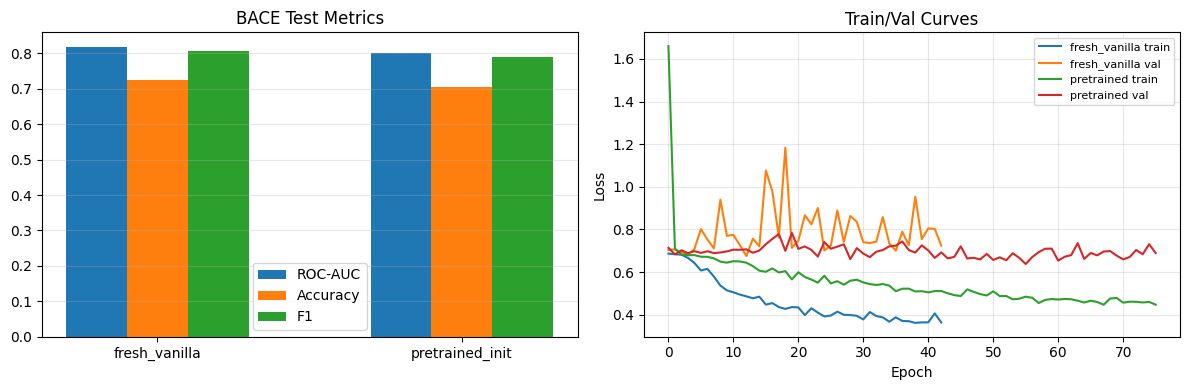

Selected thresholds:
{'fresh_vanilla': 0.21499999999999997, 'pretrained_init': 0.22999999999999998}
Fresh vanilla: {'roc_auc': 0.8184782608695652, 'accuracy': 0.7236842105263158, 'f1': 0.8073394495412844}
Pretrained init: {'roc_auc': 0.8, 'accuracy': 0.7039473684210527, 'f1': 0.7887323943661971}

Delta (pretrained - fresh_vanilla):
{'roc_auc': -0.018478260869565166, 'accuracy': -0.019736842105263164, 'f1': -0.018607055175087317}


In [ ]:
# Vergleich visualisieren
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Test metrics
x = np.arange(2)
labels = ["fresh_vanilla", "pretrained_init"]
auc_vals = [fresh_metrics["roc_auc"], pre_metrics["roc_auc"]]
acc_vals = [fresh_metrics["accuracy"], pre_metrics["accuracy"]]
f1_vals = [fresh_metrics["f1"], pre_metrics["f1"]]

axes[0].bar(x - 0.2, auc_vals, width=0.2, label="ROC-AUC")
axes[0].bar(x, acc_vals, width=0.2, label="Accuracy")
axes[0].bar(x + 0.2, f1_vals, width=0.2, label="F1")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_title("BACE Test Metrics")
axes[0].grid(alpha=0.3, axis="y")
axes[0].legend()

# Training curves (loss)
fresh_val_curve = fresh_hist.get("val_loss", fresh_hist.get("val_metric", []))
pre_val_curve = pre_hist.get("val_loss", pre_hist.get("val_metric", []))
axes[1].plot(fresh_hist["train_loss"], label="fresh_vanilla train")
axes[1].plot(fresh_val_curve, label="fresh_vanilla val")
axes[1].plot(pre_hist["train_loss"], label="pretrained train")
axes[1].plot(pre_val_curve, label="pretrained val")
axes[1].set_title("Train/Val Curves")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].grid(alpha=0.3)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

print("Selected thresholds:")
print({"fresh_vanilla": float(fresh_thr), "pretrained_init": float(pre_thr)})
print("Fresh vanilla:", fresh_metrics)
print("Pretrained init:", pre_metrics)
print("\nDelta (pretrained - fresh_vanilla):")
print(
    {
        "roc_auc": pre_metrics["roc_auc"] - fresh_metrics["roc_auc"],
        "accuracy": pre_metrics["accuracy"] - fresh_metrics["accuracy"],
        "f1": pre_metrics["f1"] - fresh_metrics["f1"],
    }
)